# Notebook 5: Visualización con t-SNE

**Proyecto Final - Inteligencia Artificial**

Este notebook genera las visualizaciones que muestran **cómo se organizan los embeddings en el espacio vectorial**. Usamos t-SNE (van der Maaten & Hinton, 2008) para proyectar los vectores de alta dimensión a 2D, conservando la estructura local.

## Qué visualizamos

1. **Embeddings de palabras**: tomamos las palabras más frecuentes del vocabulario y vemos cómo se agrupan según cada modelo (w2v PyTorch, w2v gensim, GloVe). Se espera ver clusters semánticos: números, países, partes del cuerpo, verbos comunes, etc.

2. **Embeddings de documentos**: las 5.000 entradas del corpus de mMARCO proyectadas. Se espera que con SBERT haya estructura clara (clusters temáticos), y menos con métodos basados en promedio de palabras.

3. **Visualización de queries y sus resultados**: para una query dada, mostramos dónde está la query y los top-5 documentos en el espacio 2D.



## 1. Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/proyecto_ia_final"
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Trabajando en: {os.getcwd()}")

Mounted at /content/drive
Trabajando en: /content/drive/MyDrive/proyecto_ia_final


In [ ]:
!pip install scikit-learn matplotlib seaborn -q

In [ ]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

DATA_DIR = Path("data")
sns.set_style("whitegrid")


## 2. Cargar datos

In [ ]:
# Vocabulario
with open(DATA_DIR / "vocab.json", "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
word2id = vocab_data["word2id"]
id2word = {int(k): v for k, v in vocab_data["id2word"].items()}

# Embeddings de palabra
w2v_pytorch = np.load(DATA_DIR / "word2vec_pytorch.npy")
w2v_gensim  = np.load(DATA_DIR / "word2vec_gensim.npy")
glove       = np.load(DATA_DIR / "glove_aligned.npy")
glove_mask  = np.load(DATA_DIR / "glove_vocab_mask.npy")

# Embeddings de documento (del notebook 4)
doc_emb_w2v_pytorch = np.load(DATA_DIR / "doc_emb_w2v_pytorch.npy")
doc_emb_sbert       = np.load(DATA_DIR / "doc_emb_sbert.npy")

# Textos de los documentos
with open(DATA_DIR / "eval_docs.json", "r", encoding="utf-8") as f:
    eval_data = json.load(f)
all_docs = eval_data["all_docs"]
eval_queries = eval_data["eval_queries"]

print(f"Cargado todo.")
print(f"Documentos: {len(all_docs):,}")
print(f"Queries:    {len(eval_queries):,}")


Cargado todo.
Documentos: 5,000
Queries:    200


## 3. t-SNE sobre embeddings de palabras

Tomamos las N palabras más frecuentes (las primeras N del vocabulario, ya que está ordenado por frecuencia) y las proyectamos.

In [ ]:
# Cuántas palabras visualizar
N_WORDS = 1500

# Palabras a etiquetar específicamente en el gráfico
LABEL_WORDS = [
    # Países
    "españa", "francia", "alemania", "italia", "méxico", "colombia", "argentina", "chile",
    # Ciudades
    "madrid", "parís", "berlín", "roma", "barcelona", "bogotá",
    # Familia
    "padre", "madre", "hijo", "hija", "hermano", "hermana",
    # Tiempo
    "lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo",
    "enero", "febrero", "marzo", "abril",
    # Otros
    "rey", "reina", "música", "guerra", "amor", "casa", "agua", "fuego",
]

def run_tsne(embeddings, n_iter=1000, perplexity=30):
    tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=n_iter,
                random_state=42, init='pca', learning_rate='auto')
    return tsne.fit_transform(embeddings)


In [ ]:
# Ejecutar t-SNE para cada modelo de palabras
print("Calculando t-SNE para Word2Vec (PyTorch)...")
tsne_w2v_pytorch = run_tsne(w2v_pytorch[:N_WORDS])

print("Calculando t-SNE para Word2Vec (gensim)...")
tsne_w2v_gensim = run_tsne(w2v_gensim[:N_WORDS])

print("Calculando t-SNE para GloVe...")
# Solo usar palabras con vector GloVe
glove_indices = np.where(glove_mask[:N_WORDS])[0]
tsne_glove = run_tsne(glove[glove_indices])

print("¡Listo!")


Calculando t-SNE para Word2Vec (PyTorch)...
Calculando t-SNE para Word2Vec (gensim)...
Calculando t-SNE para GloVe...
¡Listo!


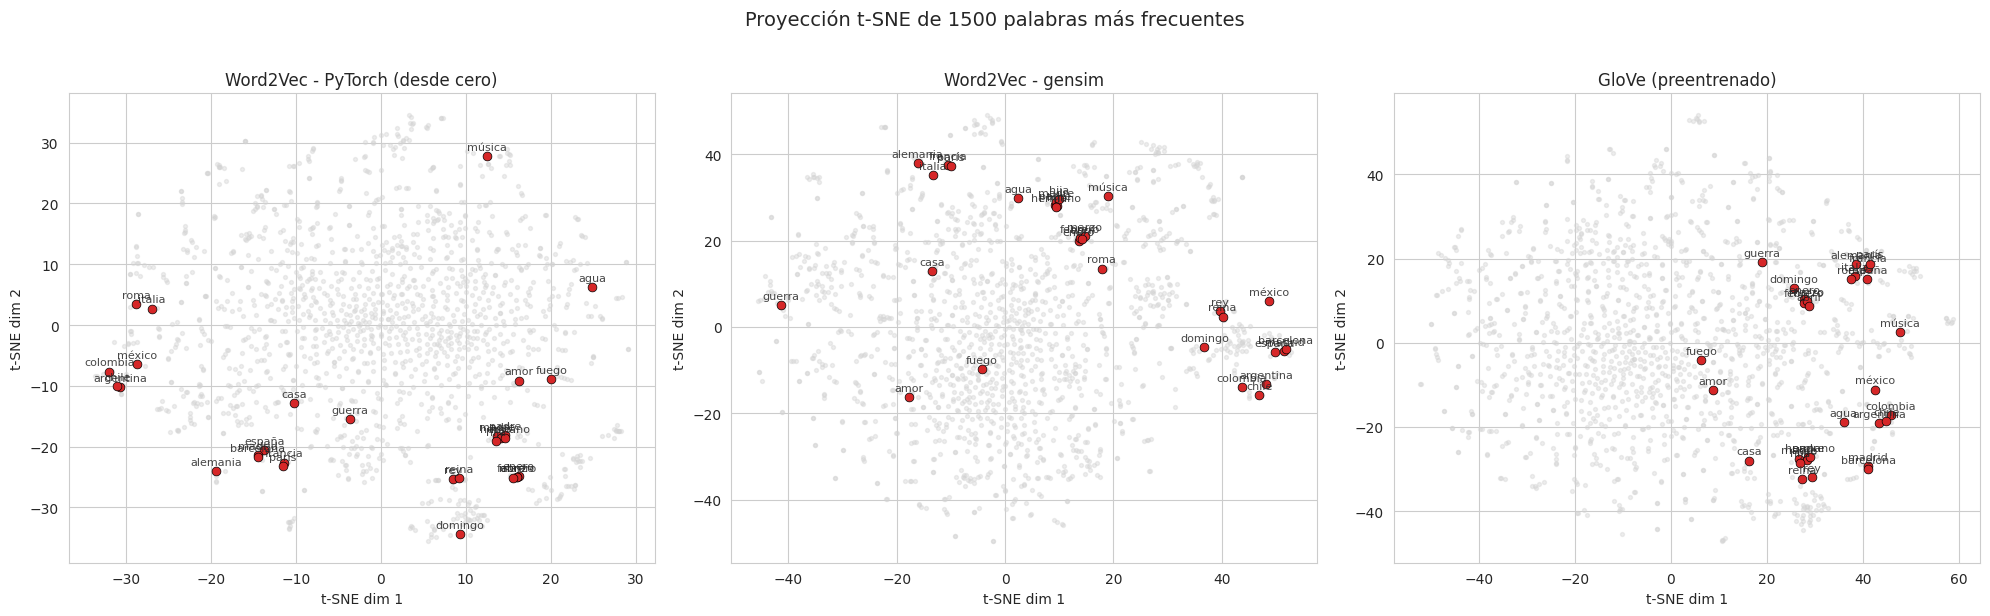

Gráfico guardado: data/tsne_words.png


In [ ]:
def plot_word_tsne(coords, indices_used, title, ax, label_words):

    # Plot todos los puntos en gris claro
    ax.scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.4, c='lightgray')

    # Resaltar palabras etiquetables
    for word in label_words:
        if word in word2id:
            wid = word2id[word]
            # Buscar la posición de wid dentro de indices_used
            pos = np.where(indices_used == wid)[0]
            if len(pos) > 0:
                p = pos[0]
                ax.scatter(coords[p, 0], coords[p, 1], s=40, c='C3', edgecolors='black', linewidth=0.5)
                ax.annotate(word, (coords[p, 0], coords[p, 1]),
                           fontsize=8, alpha=0.85, ha='center', va='bottom',
                           xytext=(0, 3), textcoords='offset points')

    ax.set_title(title)
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Word2Vec PyTorch
plot_word_tsne(tsne_w2v_pytorch, np.arange(N_WORDS),
               f"Word2Vec - PyTorch (desde cero)", axes[0], LABEL_WORDS)

# Word2Vec gensim
plot_word_tsne(tsne_w2v_gensim, np.arange(N_WORDS),
               f"Word2Vec - gensim", axes[1], LABEL_WORDS)

# GloVe
plot_word_tsne(tsne_glove, glove_indices,
               f"GloVe (preentrenado)", axes[2], LABEL_WORDS)

plt.suptitle(f"Proyección t-SNE de {N_WORDS} palabras más frecuentes",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "tsne_words.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado: data/tsne_words.png")


## 4. Zoom sobre grupos semánticos específicos

Filtramos solo las palabras de ciertas categorías y vemos si quedan agrupadas (lo cual indicaría que los embeddings capturan la semántica).

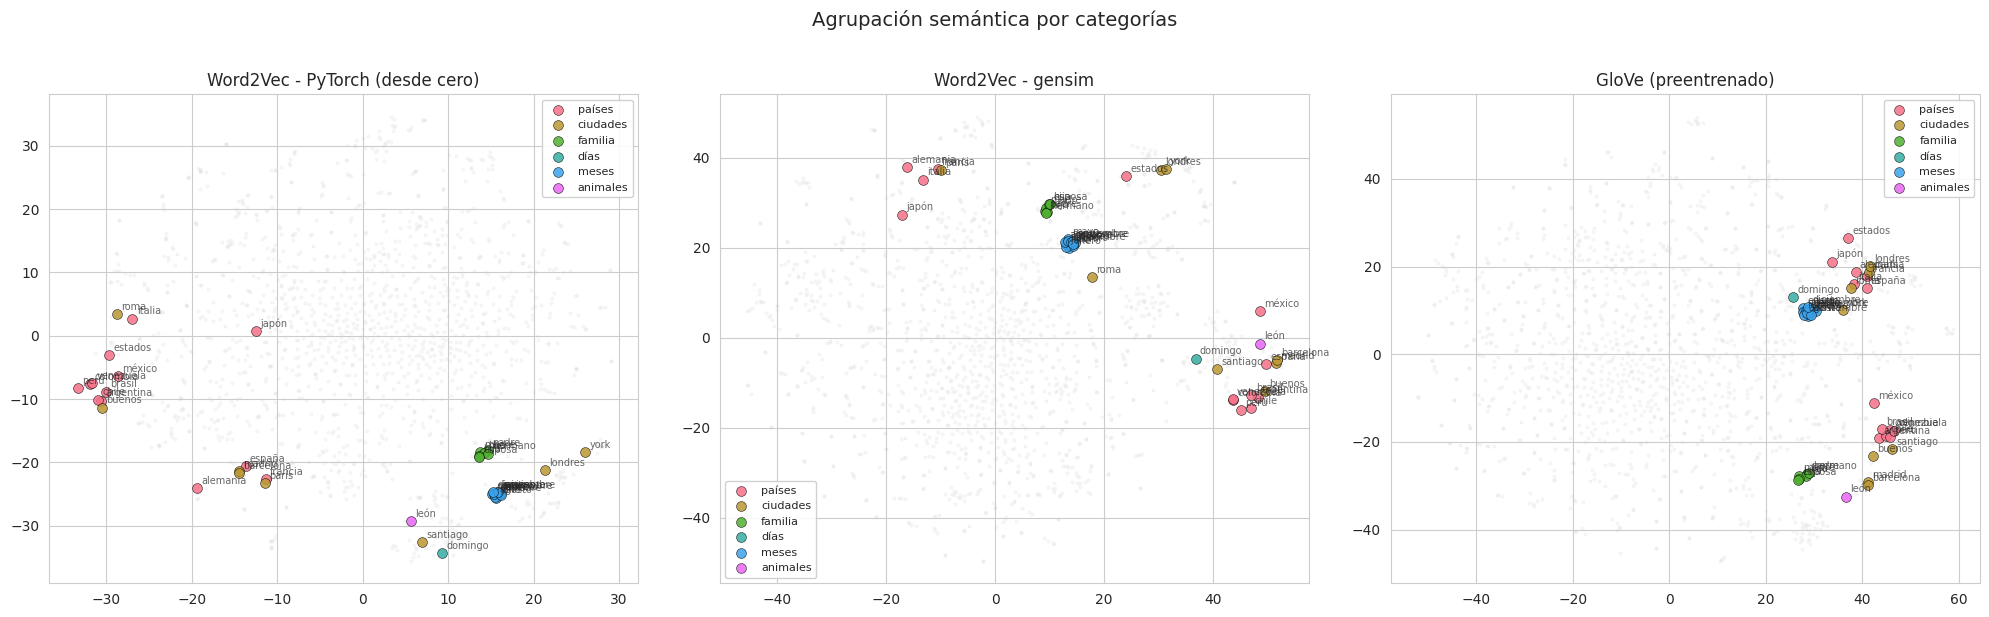

Gráfico guardado: data/tsne_categories.png


In [ ]:
# Definir categorías semánticas para colorear
categories = {
    'países':  ["españa", "francia", "alemania", "italia", "méxico", "colombia",
                "argentina", "chile", "perú", "venezuela", "brasil", "estados", "japón"],
    'ciudades': ["madrid", "parís", "berlín", "roma", "barcelona", "bogotá",
                 "buenos", "santiago", "londres", "tokio", "york"],
    'familia': ["padre", "madre", "hijo", "hija", "hermano", "hermana",
                "abuelo", "abuela", "tío", "tía", "primo", "esposa", "esposo"],
    'días':    ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"],
    'meses':   ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio",
                "agosto", "septiembre", "octubre", "noviembre", "diciembre"],
    'animales': ["perro", "gato", "caballo", "vaca", "pez", "ave", "león", "tigre"],
}


def plot_categories(coords, indices_used, title, ax):
    """Plot con colores por categoría."""
    # Fondo: todos los puntos en gris
    ax.scatter(coords[:, 0], coords[:, 1], s=4, alpha=0.15, c='lightgray')

    # Cada categoría con un color
    palette = sns.color_palette("husl", len(categories))
    for (cat, words), color in zip(categories.items(), palette):
        points = []
        labels = []
        for w in words:
            if w in word2id:
                wid = word2id[w]
                pos = np.where(indices_used == wid)[0]
                if len(pos) > 0:
                    points.append(coords[pos[0]])
                    labels.append(w)
        if points:
            points = np.array(points)
            ax.scatter(points[:, 0], points[:, 1], s=50, c=[color],
                      label=cat, edgecolors='black', linewidth=0.4, alpha=0.85)
            for (x, y), lbl in zip(points, labels):
                ax.annotate(lbl, (x, y), fontsize=7, alpha=0.7,
                           xytext=(3, 3), textcoords='offset points')

    ax.set_title(title)
    ax.legend(loc='best', fontsize=8, framealpha=0.9)


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_categories(tsne_w2v_pytorch, np.arange(N_WORDS),
                "Word2Vec - PyTorch (desde cero)", axes[0])
plot_categories(tsne_w2v_gensim, np.arange(N_WORDS),
                "Word2Vec - gensim", axes[1])
plot_categories(tsne_glove, glove_indices,
                "GloVe (preentrenado)", axes[2])

plt.suptitle("Agrupación semántica por categorías", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "tsne_categories.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado: data/tsne_categories.png")


## 5. t-SNE sobre embeddings de documentos

Visualizamos los 5.000 documentos del corpus de mMARCO en 2D. Comparamos word2vec (mean pooling) vs SBERT.

In [ ]:
# Submuestrear para que t-SNE no tarde demasiado
N_DOCS_VIS = min(2000, len(all_docs))
sample_indices = np.random.RandomState(42).choice(len(all_docs), N_DOCS_VIS, replace=False)

print(f"Calculando t-SNE para documentos (N={N_DOCS_VIS})...")

print("  Word2Vec (PyTorch)...")
tsne_docs_w2v = run_tsne(doc_emb_w2v_pytorch[sample_indices])

print("  SBERT...")
tsne_docs_sbert = run_tsne(doc_emb_sbert[sample_indices])

print("¡Listo!")


Calculando t-SNE para documentos (N=2000)...
  Word2Vec (PyTorch)...
  SBERT...
¡Listo!


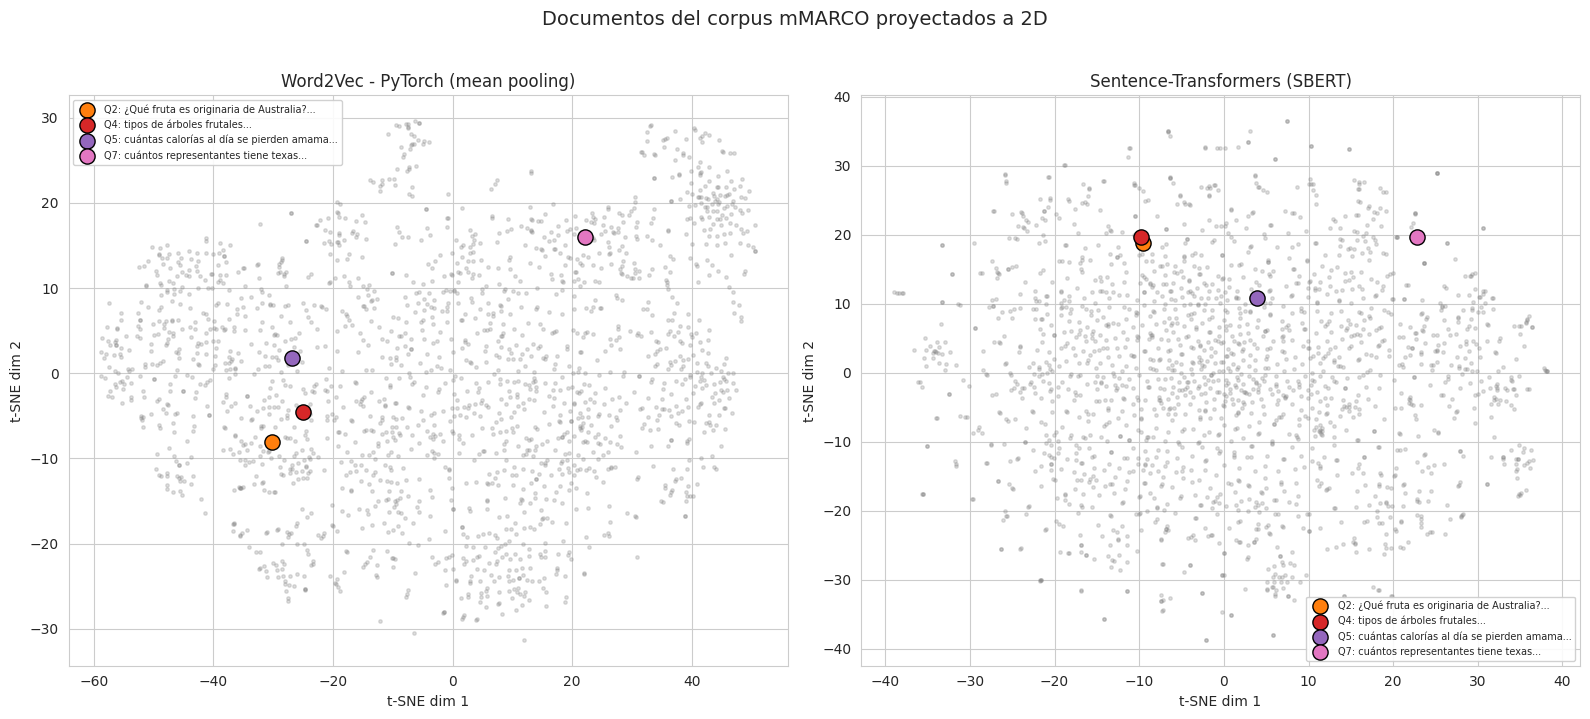

Gráfico guardado: data/tsne_documents.png


In [ ]:
# Visualizar: documentos relevantes a las primeras N queries quedan resaltados
N_HIGHLIGHT_QUERIES = 8
sampled_doc_set = set(sample_indices.tolist())
sample_pos = {doc_idx: i for i, doc_idx in enumerate(sample_indices)}

# Asignar color por query (solo si el doc relevante está en la muestra)
relevant_groups = {}
for qi, q in enumerate(eval_queries[:N_HIGHLIGHT_QUERIES]):
    if q['relevant_idx'] in sampled_doc_set:
        relevant_groups[qi] = sample_pos[q['relevant_idx']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

palette = sns.color_palette("tab10", N_HIGHLIGHT_QUERIES)

for ax, coords, title in [(axes[0], tsne_docs_w2v, "Word2Vec - PyTorch (mean pooling)"),
                          (axes[1], tsne_docs_sbert, "Sentence-Transformers (SBERT)")]:
    ax.scatter(coords[:, 0], coords[:, 1], s=6, alpha=0.25, c='gray')
    for qi, doc_pos in relevant_groups.items():
        ax.scatter(coords[doc_pos, 0], coords[doc_pos, 1],
                   s=120, c=[palette[qi]],
                   edgecolors='black', linewidth=1,
                   label=f"Q{qi+1}: {eval_queries[qi]['query'][:40]}...")
    ax.set_title(title)
    ax.legend(loc='best', fontsize=7, framealpha=0.9)
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")

plt.suptitle("Documentos del corpus mMARCO proyectados a 2D", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "tsne_documents.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado: data/tsne_documents.png")


## 6. Visualización: una query y sus top-K resultados

Tomamos UNA query, calculamos su embedding y los embeddings de los top-K documentos según cada método, y los proyectamos juntos para ver la "geografía" de la búsqueda.

Query: 'está bien un poco de cafeína durante el embarazo'
Documento relevante: 'No sabemos mucho sobre los efectos de la cafeína durante el embarazo en usted y su bebé. Por lo tanto, es mejor limitar la cantidad que recibe cada día. Si está embarazada, limite la cafeína a 200 mil...'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Proyectando con t-SNE...


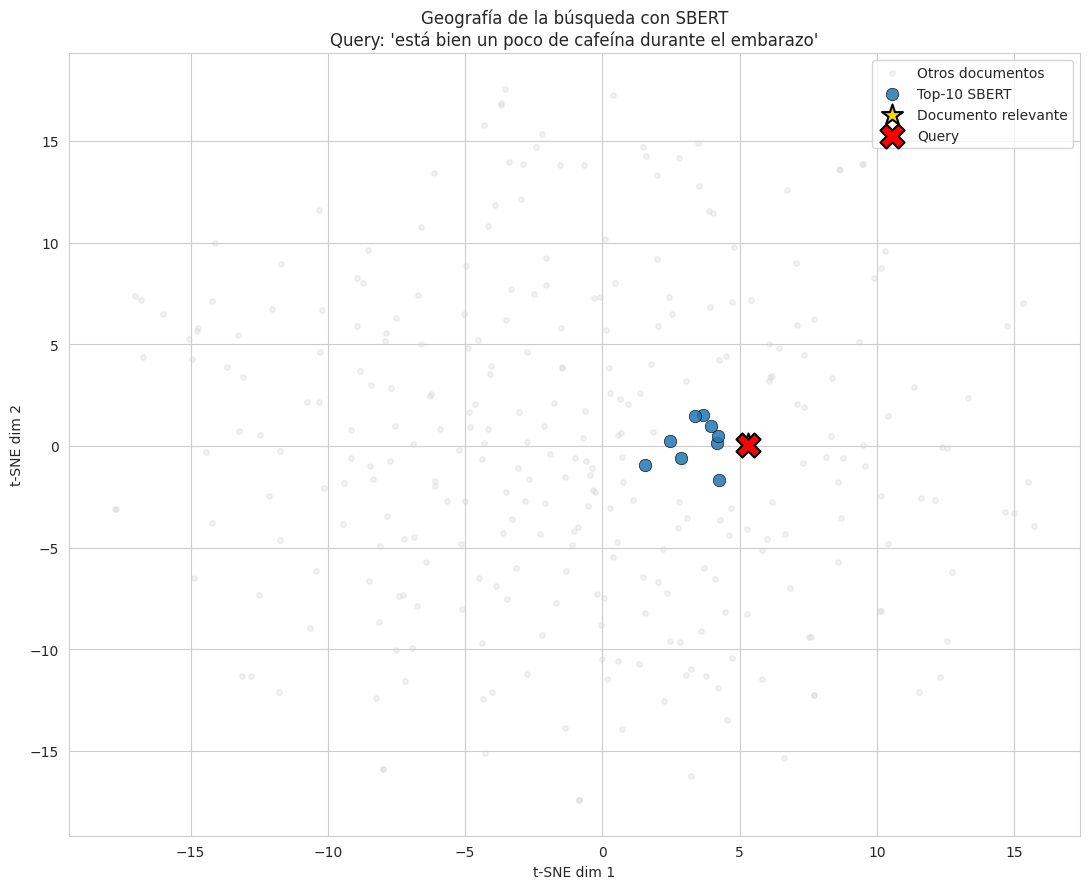

Gráfico guardado: data/tsne_query_results.png


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Para esta visualización necesitamos también los query embeddings.
# Como solo tenemos los doc_embs guardados, recalculamos query embs para esa query con SBERT.
from sentence_transformers import SentenceTransformer
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

QUERY_IDX = 0  # Cambia este índice para ver otras queries
query_text = eval_queries[QUERY_IDX]['query']
relevant_idx = eval_queries[QUERY_IDX]['relevant_idx']

print(f"Query: '{query_text}'")
print(f"Documento relevante: '{all_docs[relevant_idx][:200]}...'")

sbert = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2").to(device)
query_emb = sbert.encode([query_text], convert_to_numpy=True)

# Top-10 con SBERT
sims = cosine_similarity(query_emb, doc_emb_sbert)[0]
top10_sbert = np.argsort(-sims)[:10]

# Construir conjunto: query + top10 + algunos distractores
distractor_indices = np.random.RandomState(42).choice(
    [i for i in range(len(all_docs)) if i not in top10_sbert and i != relevant_idx],
    300, replace=False
)
viz_indices = list(top10_sbert) + [relevant_idx] + list(distractor_indices)
viz_indices = list(dict.fromkeys(viz_indices))  # deduplicar conservando orden

# Stack: doc embeddings + query embedding al final
viz_embs = np.vstack([doc_emb_sbert[viz_indices], query_emb])

print(f"\nProyectando con t-SNE...")
tsne_query = run_tsne(viz_embs, perplexity=15)

# Visualizar
fig, ax = plt.subplots(figsize=(11, 9))

# Distractores
ax.scatter(tsne_query[11:-1, 0], tsne_query[11:-1, 1], s=15, alpha=0.3, c='lightgray', label='Otros documentos')

# Top-10 (sin contar el relevante, que se resalta aparte)
top10_in_viz = [viz_indices.index(d) for d in top10_sbert if d != relevant_idx]
ax.scatter(tsne_query[top10_in_viz, 0], tsne_query[top10_in_viz, 1],
           s=80, c='C0', edgecolors='black', linewidth=0.5, alpha=0.85, label='Top-10 SBERT')

# Documento relevante
rel_pos = viz_indices.index(relevant_idx)
ax.scatter(tsne_query[rel_pos, 0], tsne_query[rel_pos, 1],
           s=250, c='gold', marker='*', edgecolors='black', linewidth=1.5,
           label='Documento relevante')

# Query
ax.scatter(tsne_query[-1, 0], tsne_query[-1, 1],
           s=300, c='red', marker='X', edgecolors='black', linewidth=1.5,
           label='Query')

ax.set_title(f"Geografía de la búsqueda con SBERT\nQuery: '{query_text}'", fontsize=12)
ax.legend(loc='best')
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")

plt.tight_layout()
plt.savefig(DATA_DIR / "tsne_query_results.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Gráfico guardado: data/tsne_query_results.png")
